<a href="https://colab.research.google.com/github/AmrrinMalikha/Qiskit_single_qubit_gates/blob/main/Qiskit_single_qubit_gates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install qiskit qiskit-aer --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.8 MB/s eta 0:00:00


In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator


In [11]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# Initialize simulator
sim = AerSimulator()

# Create a single-qubit circuit with one classical bit
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)

# --- Apply sequence of single-qubit gates ---
#qc.x(0)        # Pauli-X (NOT gate)
#qc.h(0)        # Hadamard (superposition)
#qc.h(0)
#qc.s(0)        # Phase gate (π/2)
#qc.t(0)        # T gate (π/4)
#qc.rz(0.5, 0)  # Z-axis rotation by 0.5 radians

# Measure final state
qc.measure_all()

# Display circuit
print("Quantum Circuit:")
print(qc.draw())

# --- Run simulation ---
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=2000).result() #shots - no.of time doing the task

# --- Display results ---
counts = result.get_counts() #key and values 0 0 , 1 0 in one particular cubit register will be same it is stored in a 0
print("\nMeasurement Counts:", counts)


Quantum Circuit:
        ┌───┐           ░ ┌─┐      
   q_0: ┤ H ├──■────■───░─┤M├──────
        └───┘┌─┴─┐  │   ░ └╥┘┌─┐   
   q_1: ─────┤ X ├──┼───░──╫─┤M├───
             └───┘┌─┴─┐ ░  ║ └╥┘┌─┐
   q_2: ──────────┤ X ├─░──╫──╫─┤M├
                  └───┘ ░  ║  ║ └╥┘
   c: 3/═══════════════════╬══╬══╬═
                           ║  ║  ║ 
meas: 3/═══════════════════╩══╩══╩═
                           0  1  2 

Measurement Counts: {'000 000': 968, '111 000': 1032}


In [32]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
sim = AerSimulator()
n = 10
qc = QuantumCircuit(n, n)
for i in range(n):
    qc.h(i)
qc.measure(list(range(n)), list(range(n)))
sim = AerSimulator()
tqc = transpile(qc,sim)
result = sim.run(tqc,shots=1).result()

counts = result.get_counts()
random_bit = list(counts.keys())[0]

print("Random Bit : ", random_bit)
print("Random decimal : " ,int(random_bit,2))

Random Bit :  1010101001
Random decimal :  681


In [36]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

sim = AerSimulator()
n = 3  # Number of qubits
qc = QuantumCircuit(n, n)

# Apply Hadamard gate to all qubits for superposition
for i in range(n):
    qc.h(i)

# Measure all qubits into classical bits
qc.measure(list(range(n)), list(range(n)))

# Transpile the circuit for the simulator
tqc = transpile(qc, sim)

# Run the simulation 4 times (shots=4) with memory=True
result = sim.run(tqc, shots=4, memory=True).result()

# Get the individual measurement outcomes (memory) for each shot
# This gives a list of binary strings, one for each shot.
individual_results = result.get_memory()

# Combine the binary strings from all shots into one long binary string
combined_binary_string = "".join(individual_results)

# Convert the combined binary string to a decimal integer
combined_decimal_otp = int(combined_binary_string, 2)

print(f"Individual Binary Results (from 4 shots): {individual_results}")
print(f"Combined Binary String: {combined_binary_string}")
print(f"Generated 4-digit OTP (Decimal): {combined_decimal_otp}")

Individual Binary Results (from 4 shots): ['010', '011', '100', '100']
Combined Binary String: 010011100100
Generated 4-digit OTP (Decimal): 1252


In [20]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

sim = AerSimulator()

# Create a quantum circuit with 10 qubits and 10 classical bits
qc = QuantumCircuit(10, 10)

# Apply Hadamard gate to all 10 qubits
for i in range(10):
    qc.h(i)

# Measure all qubits into their corresponding classical bits
qc.measure(list(range(10)), list(range(10)))

# Transpile the circuit for the simulator
tqc = transpile(qc, sim)

# Run the simulation with 4 shots
result = sim.run(tqc, shots=1).result()

# Get the measurement counts
counts = result.get_counts()

print("Counts : ", counts)

# Convert binary keys to decimal values (OTPs)
print("\nRandomly Generated OTPs (Decimal from Binary Measurements):")
for binary_result in counts.keys():
    # The keys are strings, e.g., '1011001101'. Convert from binary to decimal.
    decimal_otp = int(binary_result, 2)
    print(f"Binary: {binary_result} Decimal OTP: {decimal_otp}")

Counts :  {'0010110001': 1}

Randomly Generated OTPs (Decimal from Binary Measurements):
Binary: 0010110001 -> Decimal OTP: 177


In [37]:
pip install numpy matplotlib scikit-learn

Accuracy: 0.9861111111111112

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



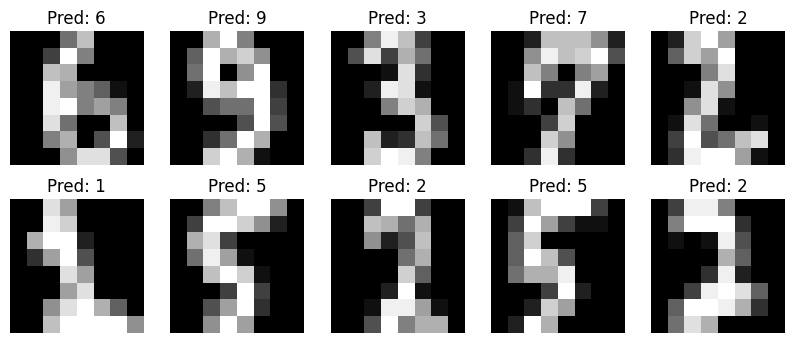

In [38]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Step 2: Load MNIST dataset (digits dataset from sklearn)
digits = datasets.load_digits()

# Step 3: Features and labels
X = digits.data      # Flattened images (64 features per image)
y = digits.target    # Labels (0–9)

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 5: Create SVM model
model = SVC(kernel='rbf')  # RBF kernel is best for non-linear data

# Step 6: Train the model
model.fit(X_train, y_train)

# Step 7: Predictions
y_pred = model.predict(X_test)

# Step 8: Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Step 9: Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Step 10: Visualize some predictions
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')
plt.show()

In [40]:
!pip install qiskit qiskit-machine-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 4.8 MB/s eta 0:00:00


In [41]:
# Step 1: Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Qiskit imports
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# Step 2: Load dataset (MNIST)
mnist = fetch_openml('mnist_784', version=1)
x = mnist.data.to_numpy()
y = mnist.target.astype(int).to_numpy()

# Step 3: Reduce dataset size (for speed)
x = x[:2000]
y = y[:2000]

# Step 4: Keep only digits 0 and 1 (binary classification)
mask = (y == 0) | (y == 1)
x = x[mask]
y = y[mask]

# Step 5: Normalize data
scaler = MinMaxScaler()
x = scaler.fit_transform(x)

# Step 6: Reduce dimensions (VERY IMPORTANT for quantum)
pca = PCA(n_components=2)
x_reduced = pca.fit_transform(x)

# Step 7: Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x_reduced, y, test_size=0.2, random_state=42
)

# Step 8: Quantum Feature Map
feature_map = ZZFeatureMap(feature_dimension=2, reps=2)

# Step 9: Quantum Kernel
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

# Step 10: QSVM using classical SVM + quantum kernel
qsvm = SVC(kernel=quantum_kernel.evaluate)

# Step 11: Train
qsvm.fit(x_train, y_train)

# Step 12: Predict
y_pred = qsvm.predict(x_test)

# Step 13: Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Predictions:", y_pred[:10])
print("Actual:", y_test[:10])
print("Accuracy:", accuracy)

/tmp/ipykernel_11472/2618195725.py:44: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)


Predictions: [0 0 1 1 0 1 0 1 1 1]
Actual: [0 0 1 0 0 1 0 1 0 1]
Accuracy: 0.6385542168674698
